# Hacia un "instrumento" 
- Modulando señal
- Envolventes


### Oscilador básico


<center>
<img src="media/osc.jpg" width="400" />
</center>




### Hemos visto modulación en volumen o amplitud (**AM, amplitude modulation**): el volumen de la señal se modula multiplicándola por otro oscilador de baja frecuencia $f_m$ (LFO, low frequency oscilator)

  - Matemáticamente con dos osciladores sería algo así:

    $$ sin(2\pi f) ~~ *~~ (sin(2*\pi f_m)+k)*k' \textrm{~~~~~~~ (k y k' para trasladar la moduladora a $[v_0,v_1]$ con $0\le v_o < v_1\le 1$ })$$

<center>
<img src="media/am.png" width="600" />
</center>



### Y si modulamos la propia frecuencia $f$... idea de la síntesis $FM$ (frecuencia modulada):





Matemáticamente:


$${sin(2\pi f_c+\beta \underbrace{sin(2\pi f_m))}_{\textrm{moduladora}}}$$

<center>
<img src="media/fm.png" width="600" />
</center>


-   $f_c$ frecuencia portadora (**carrier**) $\leadsto$ pitch de la nota.

-   $f_m$ frecuencia moduladora (**modulator**) $\leadsto$ vibrato

-   $\beta$ índice de modulación (modulator **index**)
   


<center>
<img src="media/oscFM.jpg" width="400" />
</center>


In [4]:
%%writefile oscFM.py

import numpy as np   
import osc
import matplotlib.pyplot as plt
from consts import *

class OscFM:
    def __init__(self,fc=110.0,amp=1.0,fm=6.0, beta=1.0):
        self.fc = fc
        self.amp = amp
        self.fm = fm
        self.beta = beta
        self.frame = 0

        # moduladora = βsin(2πfm)
        self.mod = osc.Osc(freq=fm,amp=beta)
        
    def next(self):  
        # sin(2πfc+mod)  
        # sacamos el siguiente chunk de la moduladora
        mod = self.mod.next()

        # soporte para el chunk de salida
        sample = np.arange(self.frame,self.frame+CHUNK)        
        # aplicamos formula
        out =  self.amp*np.sin(2*np.pi*self.fc*sample/SRATE + mod)
        self.frame += CHUNK
        return out 

    def setBeta(self,beta):
        self.beta = beta
        self.mod.amp = beta

    def setFm(self,fm):
        self.fm = fm
        self.mod.freq = fm

    def getBeta(self):
        return self.beta    

    def getFm(self):
        return self.fm

        

Overwriting oscFM.py


In [5]:
# para recargar los módulos editados sin tener que reiniciar el kernel

%load_ext autoreload
%autoreload 2

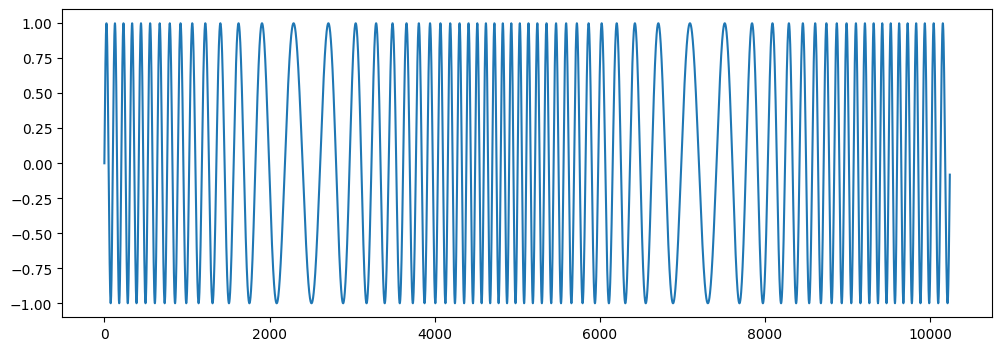

In [19]:
from oscFM import *

# oscilador FM    
# o = OscFM(fc=20,fm=1000,beta=0.1)
o = OscFM(fc=290,fm=10,beta=18)

# concatenamos 3 chunks y dibujamos
plt.rcParams['figure.figsize'] = [12, 4]
sgn = np.zeros(0)
for i in range(10):
    sgn = np.concatenate((sgn,o.next()))
plt.plot(sgn)

plt.rcParams['figure.figsize'] = [10, 5]

 ### Efecto vibrato!!

In [6]:
# también podemos hacerlo sonar
from oscFM import *
import sounddevice as sd
# oscilador FM    
o = OscFM(amp=0.2,fc=220,fm=1000,beta=0.1)

# concatenamos 30 chunks y hacemos sonar 
# 
sgn = np.zeros(0)
for i in range(100): # 100*CHUNK = 102400; 102400/SRATE = 2.13 segundos
    sgn = np.concatenate((sgn,o.next()))

sd.play(sgn)

# Un experimento con FM

Vamos a variar dinámicamente la frecuencia de la moduladora y el coficiente beta

Dejamos fija la frecuencia fundamental y su amplitud

In [7]:
from consts import *
import sounddevice as sd
from tkinter import *
from oscFM import *


def callback(outdata, frames, time, status):
    if status: print(status)
    if input:    
        s = input.next()
        s = np.float32(s)
    else:
        s = np.zeros(CHUNK,dtype=np.float32)
    outdata[:] = s.reshape(-1, 1)
stream = sd.OutputStream(samplerate=SRATE, callback=callback, blocksize=CHUNK)
stream.start()


o = OscFM(amp=0.2,fc=220,fm=1000,beta=0.1)
input = o

root=Tk()
text = Text(root,height=6,width=60)
text.pack(side=BOTTOM)
text.insert(INSERT,"Press [F/f] to modify the modulation freq, [B/b] beta\n")

# call back para la pulsación de teclas
def key_down(event):
    global o
    global input  # conexión con sounddevice
    if event.char=='F':         
        o.setFm(o.getFm()+10)
    elif event.char=='f': 
        o.setFm(o.getFm()-10)
    elif event.char=='B':        
        o.setBeta(o.getBeta()+0.1)
    elif event.char=='b':
        o.setBeta(o.getBeta()-0.1)
    text.insert(INSERT,f'fm: {o.getFm()}, beta: {o.getBeta()}\n') 

# enlace de la pulsación de teclas con la función key_down
text.bind('<Key>', key_down)

# arrancamos todo!!
root.mainloop()
# ejecución bloqueada hasta que se cierre ventana

# limpieza..
stream.stop()
stream.close()

output underflow


# Inciso: contenido armónico en FM

Vamos a generar señal modulada, ajustar la frecuencia moduladora y el índice $\beta$... y ver el contenido armónico




In [20]:
# Para linux 
# pip install -U -f https://extras.wxpython.org/wxPython4/extras/linux/gtk3/ubuntu-24.04  wxPython

%run -i 'fmPyo.py'


# modificar valores de car y mod desde el intérprete con
# car.setValue(220); mod.setValue(440)

ModuleNotFoundError: No module named 'pyo'

#### Más información

Véase https://piqued.fm/an-in-depth-exploration-into-how-fm-synthesis-works/


# Envolventes: *esculpiendo* la forma de onda


Para simular una pulsación de cuerda o una nota de un instrumento de viento, además de utilizar un timbre adecuado, hay que *dar forma* a la señal.

- En algunos instrumentos: incremento rápido de amplitud que luego desciende gradualmente (cuerdas pulsadas/percutidas).

- En otros el incremento es gradual y luego puede sostenerse en un nivel más o menos constante (cuerda frotada, vientos...)

La forma de la envolvente es característica del instrumento y muy importante para modelarlo. Cómo es en una guitarra, una flauta, etc?

Modificar la amplitud de una señal $=$ multiplicar sus muestras por un valor dado

<br>


Una envolvente es una señal especial:

- No está previsto que suene: no es un generador propiamente dicho, no se reproduce como tal

- Pero incorpora el método **next()**

- para *dar forma* a otra señal



Definimos las envolventes como lista de $n$ puntos, pares $(tiempo,valor)$ 

$$
    points = [(t_0,v_0),(t_1,v_1),...,(t_{n-1},v_{n-1})]    
$$

(También admitirá listas $(sample,valor)$ -> al final convertimos siempre tiempo a Frame)

El *comportamiento pretendido* de la envolvente es: 

- da forma a la señal **hasta que termina**

- y después *continúa indefinidamente* con el último valor $v_{n-1}$ (salida constante)


In [1]:
%%writefile env.py

import numpy as np   
import matplotlib.pyplot as plt
from consts import *

# Lo mas común es utilizar tiempos en el eje X para definir envolventes
# método para convertir tiempo a frames
def timeToFrame(t): return round(t*SRATE)

class Env:
    # points = [(t0,v0),(t1,v1),(t2,v2),...] valores de la envolvente en instantes de tiempo
    def __init__(self,points,xAxis='samples'):
        if points[0][0]!=0: # el primer tiempo tiene que ser 0
                            # podríamos autocompletar con (0,0) pero mejor dar error
            raise Exception(f'Bad defined env: initial point {points[0]}')

        # si los valores de x están en tiempo traducimos samples
        if xAxis=='time': # si está en frames en vez de tiempo convertimos a tiempos
            points = [(timeToFrame(x),y) for (x,y) in points]

        # construimos la envolvente generando segmentos entre los puntos dados
        self.env = np.zeros(0)        
        (x0,y0) = points[0]  # punto inicial
        for (x,y) in points[1:]:
            self.env = np.concatenate((
                self.env, 
                np.linspace(y0,y,x-x0+1)[:-1] # generamos x-x0+1 puntos y luego descartamos el último 
                ))                            # que vuelve a generarse en el siguiente segmento
                                              # así evitamos "meseta" entre 2 puntos  
            (x0,y0) = (x,y) # nuevo punto de origen
        

        # una vez generada la envolvente, la extendemos hasta completar el último chunk
        # con el último valor self.last: mantiene ese valor hasta el final del chunk
        # Así la longitud de la envolvente es un múltiplo de CHUNK
        # (Esto evita evita errores al multiplicar arrays en numpy)        
        restFrames = CHUNK - (points[-1][0]-points[0][0]) % CHUNK  
        self.env = np.concatenate((self.env, np.full(restFrames,points[-1][1])))        
        #restFrames = CHUNK - (points[-1][0]-points[0][0]) % CHUNK  
        #self.env = np.concatenate((self.env, np.full(restFrames,self.last)))        

        # frame actual 
        self.frame = 0
        
        # la envolvente se extiende indefinidamente con el ultimo valor 
        # no hace falta devolver chunks con ese valor por la sobrecarga del 
        # operador * en numpy: escalar*array o array*array
        self.last = self.env[-1]

    # método next del generador de señal: devuelve array de tamaño CHUNK o valor cte
    def next(self):
        # devolvemos chuncks mientras queda envolvente
        if self.frame<self.env.shape[0]:
            out = self.env[self.frame:self.frame+CHUNK]
            self.frame += CHUNK
            return out
        else: # y la última muestra cuando no quedan
            return np.array([self.last])

    # reseteo del frame en cualquier momento
    # será util después cuando esté sonando una nota y vuelva a lanzarse:
    # se para la envolvente actual y se reinicia
    def reset(self):
        self.frame = 0        
    


Writing env.py


0.0


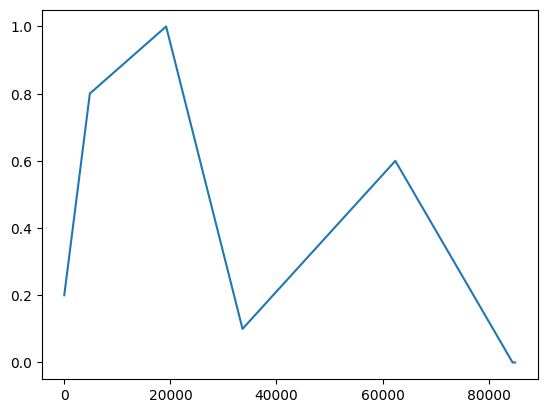

In [2]:
import env 
import numpy as np
import matplotlib.pyplot as plt

# nos inventamos una envolvente
e = env.Env([(0,0.2),(0.1,0.8),(0.4,1),(0.7,0.1),(1.3,0.6),(1.76,0)],xAxis='time')
shape = e.next()
while shape[-1]!=0:
    shape = np.concatenate((shape,e.next()))

plt.plot(shape)
print(shape[-1])


# Una envolvente especial: **ADSR**

- Attack: **tiempo** de subida de intensidad hasta el volumen máximo 

- Decay: **tiempo** de bajada hasta un estado sostenido de de amplitud (decremento de volumen)

- Sustain: **valor** (no tiempo) del volumen de la nota sostenida

- Release: **tiempo** desvanecimiento hasta el silencio (cuando se suelta la tecla)


![image](adsr.png)




Podemos modelar las envolventes mediante segmentos definidos por coordenadas.

<br>


Attack-Decay-Sustain-Release:

- Attack: define el segmento $(0,0)-(attack,1)$

- Decay:  define el segmento $(attack,1)-(attack+decay,sustain)$

- Sustain: **valor** de amplitud

- Release:  define el intervalo $(t0,sustain)-(t1,0)$ 

    - $t0$ se determina dinámicamente *cuando se desactiva la nota*

        - no se para automáticamente, sino progresivamente

    - $t1$ es tal que $t1-t0=release$


<br>

Generamos dos envolventes:

- $(0,0)-(attack,1)-(attack+decay,sustain)$

- $(0,sustain)-(release,0)$

Y se gestiona con un *Autómata finito* con 3 estados *off,act,release*

- Arranca en estado *off*

- Cuando se activa la nota pasa a *act*

    - se activa la nota y cuando acaba esa envolvente el volumen se queda en *sustain*

- Cuando se para la nota pasa a estado *release*

    - cuando acaba *release* el volumen queda a 0 y pasa a estado *off*

Observación: cuando la nota está en *attack* o *decay* puede suspenderse abruptamente.

- Permitimos este comportamiento porque *teóricamente* puede conseguirse en un instrumento real        


In [3]:
%%writefile adsr.py

import numpy as np   
import matplotlib.pyplot as plt
from consts import *
from env import *

class ADSR:
    def __init__(self,att,dec,sus,rel):
        self.act = Env([(0,0),(att,1),(att+dec,sus)],xAxis='time')
        self.sus = sus
        self.rel = Env([(0,sus),(rel,0)],xAxis='time')
        self.state = 'off' # act, rel
        self.last = 0

    def next(self):
        if self.state=='off': 
            self.last = 0
            return 0
        elif self.state=='act':             
            out = self.act.next()            
            self.last = out[-1]
            return out
        elif self.state=='rel': 
            out = self.rel.next()   
            self.last = out[-1]
            # cuando se acaba el release pasa a estado off           
            if self.last==0:
                self.state = 'off'            
            return out

    def start(self):
        self.state='act'    
        self.act.reset()

    def release(self):        
        self.rel.reset()
        self.state='rel'    


Writing adsr.py


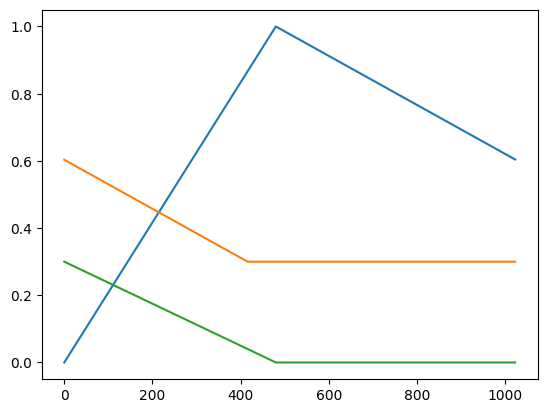

In [4]:
from adsr import *

a = ADSR(0.01,0.02,0.3,0.01)

a.state = 'act'
s = a.next()
plt.plot(s)

s = a.next()
plt.plot(s)

a.state='rel'
s = a.next()
plt.plot(s)
#
#s = a.next()
#plt.plot(s)


In [ ]:
from adsr import *

a = ADSR(0.01,0.02,0.3,0.01)

a.state = 'act'
s = a.next()

s = np.concatenate((s,a.next()))
s = np.concatenate((s,a.next()*np.ones(CHUNK))) 
                      # expandir escalar a array   

a.state='rel'
s = np.concatenate((s,a.next()))

plt.plot(s)


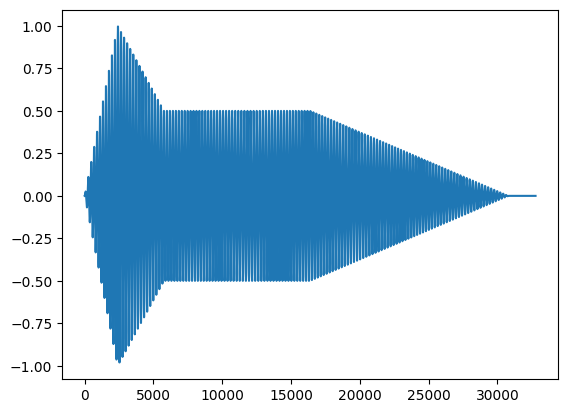

In [5]:
# generando una nota

from adsr import *
from oscFM import *
import sounddevice as sd

sig = OscFM(220)
adsr = ADSR(0.05,0.07,0.5,0.3)


# noteOn
adsr.state = 'act'

out = np.zeros(0)
for i in range(16):
    out = np.concatenate((out,sig.next()*adsr.next()))

# noteOff
adsr.state = 'rel'
for i in range(16):
    out = np.concatenate((out,sig.next()*adsr.next()))

plt.plot(out)
sd.play(out)